# TASK - 1 Dataset Preparation

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

In [52]:
# 1. Load California Housing dataset
housing = fetch_california_housing()

# Store features and target as NumPy arrays
X = housing.data
y = housing.target

print("Original feature shape:", X.shape)
print("Original target shape:", y.shape)

Original feature shape: (20640, 8)
Original target shape: (20640,)


In [53]:
# 2. Randomly shuffle and split into:
#    Training   = 60%
#    Validation = 20%
#    Test       = 20%

np.random.seed(9432)

# Create indices
indices = np.arange(len(X))

# Shuffle indices
np.random.shuffle(indices)

# Shuffle X and y using the same indices
X = X[indices]
y = y[indices]

# Calculate split sizes
n_samples = len(X)

train_size = int(0.60 * n_samples)
val_size = int(0.20 * n_samples)
test_size = n_samples - train_size - val_size

# Split the dataset
X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print("\nAfter splitting:")
print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)



After splitting:
Training set: (12384, 8) (12384,)
Validation set: (4128, 8) (4128,)
Test set: (4128, 8) (4128,)


In [54]:
# 3. Feature Normalization
# Calculate mean and standard deviation ONLY from training data

X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)

# Normalize training features
X_train = (X_train - X_mean) / X_std

# Normalize validation features using TRAINING mean/std
X_val = (X_val - X_mean) / X_std

# Normalize test features using TRAINING mean/std
X_test = (X_test - X_mean) / X_std

In [55]:
# 4. Feature Augmentation
# Add a column of 1s for the bias term

X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_val = np.c_[np.ones(X_val.shape[0]), X_val]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

In [56]:
# 5. Standardize Ground Truth Target Values
# Calculate target mean and standard deviation ONLY from training data

y_mean = np.mean(y_train)
y_std = np.std(y_train)

# Standardize training target
y_train = (y_train - y_mean) / y_std

# Standardize validation target using TRAINING parameters
y_val = (y_val - y_mean) / y_std

# Standardize test target using TRAINING parameters
y_test = (y_test - y_mean) / y_std

In [57]:
# ============================================================
# VERIFY THE PREPARATION
# ============================================================

print("\nFinal shapes:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("\nTraining feature means (excluding bias column):")
print(np.mean(X_train[:, 1:], axis=0))

print("\nTraining feature standard deviations (excluding bias column):")
print(np.std(X_train[:, 1:], axis=0))

print("\nStandardized training target mean:")
print(np.mean(y_train))

print("\nStandardized training target standard deviation:")
print(np.std(y_train))

print("\nTarget normalization parameters:")
print("y_mean =", y_mean)
print("y_std  =", y_std)


Final shapes:
X_train: (12384, 9)
X_val: (4128, 9)
X_test: (4128, 9)

Training feature means (excluding bias column):
[ 6.67028520e-15 -4.05687721e-17 -1.97551946e-15 -9.56487359e-15
 -1.04742335e-16  1.83242942e-15  2.76463194e-14 -1.64395485e-13]

Training feature standard deviations (excluding bias column):
[1. 1. 1. 1. 1. 1. 1. 1.]

Standardized training target mean:
9.78258530742063e-17

Standardized training target standard deviation:
0.9999999999999999

Target normalization parameters:
y_mean = 2.058294566375969
y_std  = 1.1574139487531678


In [58]:
import numpy as np


# ------------------------------------------------------------
# 1. MSE LOSS FUNCTION
# ------------------------------------------------------------

def mse_loss(y_true, y_pred):
    """
    Calculate Mean Squared Error.
    """
    error = y_pred - y_true
    mse = np.mean(error ** 2)
    return mse

# TASK - 2 Implement Mini-Batch Gradient Descent

In [59]:
# ------------------------------------------------------------
# 2. MINI-BATCH GRADIENT DESCENT
# ------------------------------------------------------------

def train_linear_regression(X_train, y_train, X_val, y_val,
                            learning_rate, batch_size,
                            max_epochs=1000, patience=100):

    # Number of training samples
    n_samples = X_train.shape[0]

    # Number of features including bias column
    n_features = X_train.shape[1]

    # --------------------------------------------------------
    # Initialize weights with zeros
    # --------------------------------------------------------

    weights = np.zeros(n_features)

    # Lists to store training and validation MSE
    training_losses = []
    validation_losses = []

    # Variables for early stopping
    best_val_loss = float('inf')
    best_weights = None
    best_epoch = 0
    epochs_without_improvement = 0


    # --------------------------------------------------------
    # Training loop
    # --------------------------------------------------------

    for epoch in range(max_epochs):

        # ----------------------------------------------------
        # Shuffle training data at the beginning of every epoch
        # ----------------------------------------------------

        indices = np.arange(n_samples)
        np.random.shuffle(indices)

        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]


        # ----------------------------------------------------
        # Mini-batch training
        # ----------------------------------------------------

        total_squared_error = 0.0
        total_samples_processed = 0

        # Go through training data batch by batch
        for start in range(0, n_samples, batch_size):

            # Determine end of current batch
            end = min(start + batch_size, n_samples)

            # Extract mini-batch
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            # Number of samples in this batch
            batch_n = X_batch.shape[0]


            # ------------------------------------------------
            # Forward pass
            # Prediction = XW
            # ------------------------------------------------

            y_pred_batch = X_batch @ weights


            # ------------------------------------------------
            # Calculate batch MSE
            # ------------------------------------------------

            batch_error = y_pred_batch - y_batch

            batch_mse = np.mean(batch_error ** 2)


            # ------------------------------------------------
            # Accumulate squared error
            #
            # This allows us to calculate the
            # sample-weighted average MSE at the end
            # of the epoch.
            # ------------------------------------------------

            total_squared_error += np.sum(batch_error ** 2)
            total_samples_processed += batch_n


            # ------------------------------------------------
            # Calculate gradient
            #
            # Gradient of MSE:
            #
            # gradient = (2 / batch_size) X^T (prediction - y)
            # ------------------------------------------------

            gradient = (2 / batch_n) * (X_batch.T @ batch_error)


            # ------------------------------------------------
            # Update weights
            # ------------------------------------------------

            weights = weights - learning_rate * gradient


        # ----------------------------------------------------
        # Calculate epoch training MSE
        # using sample-weighted average
        # ----------------------------------------------------

        epoch_training_mse = (
            total_squared_error / total_samples_processed
        )

        training_losses.append(epoch_training_mse)


        # ----------------------------------------------------
        # Calculate validation MSE
        #
        # IMPORTANT:
        # Validation data is ONLY used for evaluation.
        # It does NOT update the weights.
        # ----------------------------------------------------

        y_val_pred = X_val @ weights

        validation_mse = mse_loss(y_val, y_val_pred)

        validation_losses.append(validation_mse)


        # ----------------------------------------------------
        # Early Stopping
        # ----------------------------------------------------

        if validation_mse < best_val_loss:

            # New best validation loss
            best_val_loss = validation_mse

            # Save a COPY of the current weights
            best_weights = weights.copy()

            # Save epoch number
            best_epoch = epoch + 1

            # Reset patience counter
            epochs_without_improvement = 0

        else:

            # No improvement
            epochs_without_improvement += 1


        # ----------------------------------------------------
        # Print progress
        # ----------------------------------------------------

        if (epoch + 1) % 50 == 0 or epoch == 0:

            print(
                f"Epoch {epoch + 1:4d} | "
                f"Training MSE: {epoch_training_mse:.6f} | "
                f"Validation MSE: {validation_mse:.6f}"
            )


        # ----------------------------------------------------
        # Stop if validation loss has not improved
        # for 100 consecutive epochs
        # ----------------------------------------------------

        if epochs_without_improvement >= patience:

            print(
                f"\nEarly stopping at epoch {epoch + 1}"
            )

            break


    # --------------------------------------------------------
    # Return the weights corresponding to the best
    # validation MSE, NOT the weights from the final epoch
    # --------------------------------------------------------

    return (
        best_weights,
        training_losses,
        validation_losses,
        best_epoch,
        best_val_loss
    )

In [60]:
# ============================================================
# TEST TASK 2
# ============================================================

# Example learning rate
learning_rate = 0.01

# Example batch size
batch_size = 128


# Train the model
best_weights, training_losses, validation_losses, best_epoch, best_val_loss = (
    train_linear_regression(
        X_train,
        y_train,
        X_val,
        y_val,
        learning_rate,
        batch_size
    )
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 50)
print("TASK 2 RESULTS")
print("=" * 50)

print("Learning rate:", learning_rate)
print("Batch size:", batch_size)

print("Number of epochs completed:", len(training_losses))

print("Best epoch:", best_epoch)

print("Best validation MSE:", best_val_loss)

print("\nBest model weights:")
print(best_weights)

Epoch    1 | Training MSE: 0.604529 | Validation MSE: 0.471090
Epoch   50 | Training MSE: 0.391248 | Validation MSE: 0.405258
Epoch  100 | Training MSE: 0.392018 | Validation MSE: 0.393204
Epoch  150 | Training MSE: 0.392997 | Validation MSE: 0.392468
Epoch  200 | Training MSE: 0.390267 | Validation MSE: 0.403653

Early stopping at epoch 235

TASK 2 RESULTS
Learning rate: 0.01
Batch size: 128
Number of epochs completed: 235
Best epoch: 135
Best validation MSE: 0.39061677268692724

Best model weights:
[ 2.90346280e-05  7.19860627e-01  9.69540161e-02 -2.19031620e-01
  2.60323977e-01 -5.45471455e-03 -2.23757483e-02 -7.61673087e-01
 -7.33352443e-01]


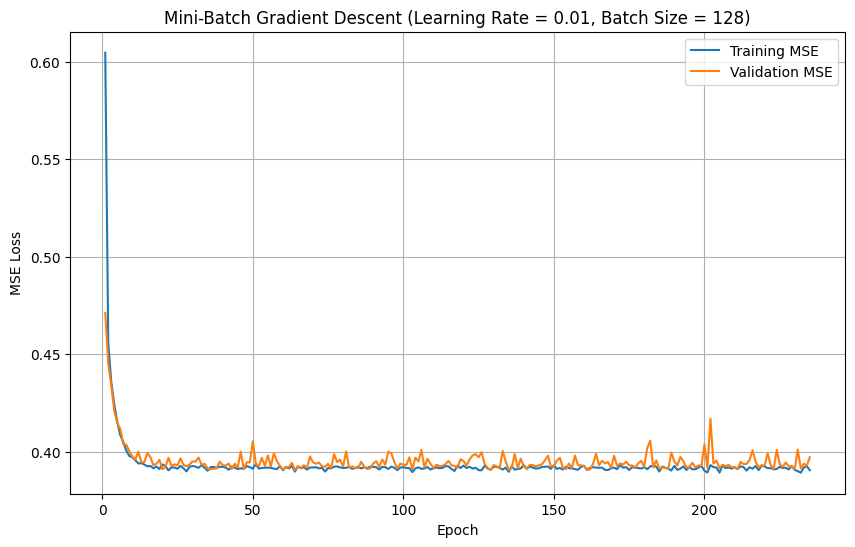

In [61]:
# ============================================================
# PLOT TRAINING AND VALIDATION MSE
# ============================================================

epochs = np.arange(1, len(training_losses) + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    training_losses,
    label="Training MSE"
)

plt.plot(
    epochs,
    validation_losses,
    label="Validation MSE"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title(
    f"Mini-Batch Gradient Descent "
    f"(Learning Rate = {learning_rate}, Batch Size = {batch_size})"
)

plt.legend()
plt.grid(True)

plt.show()

# TASK - 3 Effect of Learning Rate

In [62]:
# Learning rates required by the lab
learning_rates = [
    10**-5,
    10**-4,
    10**-3,
    10**-2,
    10**-1,
    1,
    10
]

# Batch size must remain fixed at 128
batch_size = 128


# Dictionary to store results for every learning rate
results_lr = {}


# ============================================================
# TRAIN MODEL FOR EACH LEARNING RATE
# ============================================================

for lr in learning_rates:

    print("\n" + "=" * 60)
    print(f"Training with Learning Rate = {lr}")
    print("=" * 60)

    # Train the model using the Task 2 function
    best_weights, training_losses, validation_losses, best_epoch, best_val_loss = (
        train_linear_regression(
            X_train,
            y_train,
            X_val,
            y_val,
            learning_rate=lr,
            batch_size=batch_size
        )
    )

    # Store all results
    results_lr[lr] = {
        "weights": best_weights,
        "training_losses": training_losses,
        "validation_losses": validation_losses,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss
    }


# ============================================================
# DISPLAY BEST VALIDATION RESULT FOR EACH LEARNING RATE
# ============================================================

print("\n\n")
print("=" * 70)
print("SUMMARY OF LEARNING RATE EXPERIMENT")
print("=" * 70)

for lr in learning_rates:

    result = results_lr[lr]

    print(
        f"Learning Rate = {lr:<8} | "
        f"Best Validation MSE = {result['best_val_loss']:.6f} | "
        f"Best Epoch = {result['best_epoch']}"
    )


Training with Learning Rate = 1e-05
Epoch    1 | Training MSE: 0.998967 | Validation MSE: 0.962532
Epoch   50 | Training MSE: 0.906054 | Validation MSE: 0.873966
Epoch  100 | Training MSE: 0.828691 | Validation MSE: 0.800460
Epoch  150 | Training MSE: 0.765507 | Validation MSE: 0.740652
Epoch  200 | Training MSE: 0.713751 | Validation MSE: 0.691873
Epoch  250 | Training MSE: 0.671230 | Validation MSE: 0.651988
Epoch  300 | Training MSE: 0.636196 | Validation MSE: 0.619294
Epoch  350 | Training MSE: 0.607257 | Validation MSE: 0.592436
Epoch  400 | Training MSE: 0.583280 | Validation MSE: 0.570314
Epoch  450 | Training MSE: 0.563353 | Validation MSE: 0.552040
Epoch  500 | Training MSE: 0.546741 | Validation MSE: 0.536904
Epoch  550 | Training MSE: 0.532845 | Validation MSE: 0.524326
Epoch  600 | Training MSE: 0.521179 | Validation MSE: 0.513838
Epoch  650 | Training MSE: 0.511345 | Validation MSE: 0.505059
Epoch  700 | Training MSE: 0.503022 | Validation MSE: 0.497681
Epoch  750 | Train

/tmp/ipykernel_2577/3114372848.py:13: RuntimeWarning: overflow encountered in square
  mse = np.mean(error ** 2)
/tmp/ipykernel_2577/3969266931.py:95: RuntimeWarning: overflow encountered in scalar add
  total_squared_error += np.sum(batch_error ** 2)
/tmp/ipykernel_2577/3969266931.py:84: RuntimeWarning: overflow encountered in square
  batch_mse = np.mean(batch_error ** 2)
/tmp/ipykernel_2577/3969266931.py:95: RuntimeWarning: overflow encountered in square
  total_squared_error += np.sum(batch_error ** 2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_2577/3969266931.py:107: RuntimeWarning: overflow encountered in matmul
  gradient = (2 / batch_n) * (X_batch.T @ batch


Early stopping at epoch 101

Training with Learning Rate = 1
Epoch    1 | Training MSE: 2893859789706852204277286573473966703480832968198194191759190792432180476044891914240.000000 | Validation MSE: 3112201880579394381133332331767348147190082205835971141104126051483280611725391421243392.000000
Epoch   50 | Training MSE: nan | Validation MSE: nan
Epoch  100 | Training MSE: nan | Validation MSE: nan

Early stopping at epoch 101

Training with Learning Rate = 10
Epoch    1 | Training MSE: 155969090973272524280510541505786657019467710856656109081143316225224507140547984539324880502171178669784696126606854076921802345631066411929580688746549251379261132338419867115429086612871566716231190197265491007487718588041391384301366710328912648511059277518916986714743908589896189357059444047872.000000 | Validation MSE: 30520853636897778216628671466738942570945842832877192389870655346482284972166609719740523915294117339220944457857592854399531545262576487580429924531728341180694439336328312178716049

In [63]:
# ============================================================
# FIND THE BEST LEARNING RATE
# ============================================================

best_learning_rate = min(
    learning_rates,
    key=lambda lr: results_lr[lr]["best_val_loss"]
)

best_lr_result = results_lr[best_learning_rate]


print("\n" + "=" * 70)
print("BEST LEARNING RATE")
print("=" * 70)

print("Best Learning Rate:", best_learning_rate)

print(
    "Lowest Validation MSE:",
    best_lr_result["best_val_loss"]
)

print(
    "Epoch of Lowest Validation MSE:",
    best_lr_result["best_epoch"]
)



BEST LEARNING RATE
Best Learning Rate: 0.01
Lowest Validation MSE: 0.39056579449070655
Epoch of Lowest Validation MSE: 42


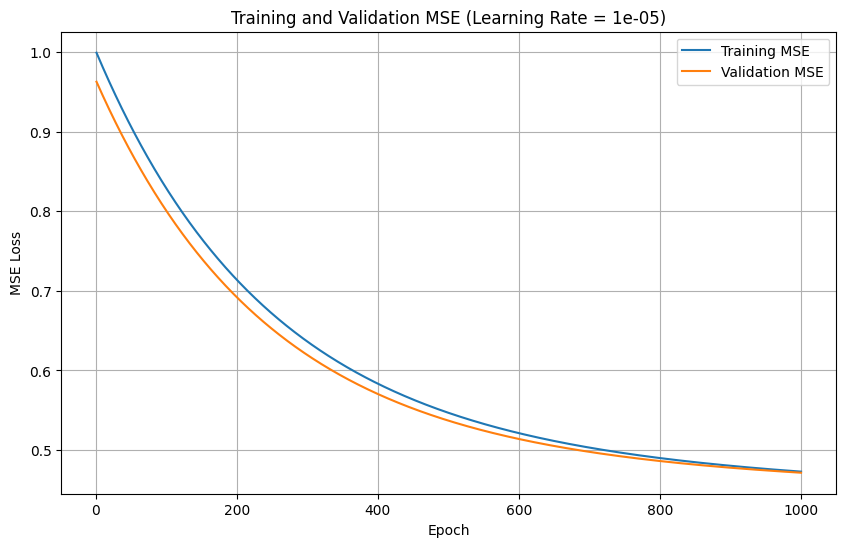

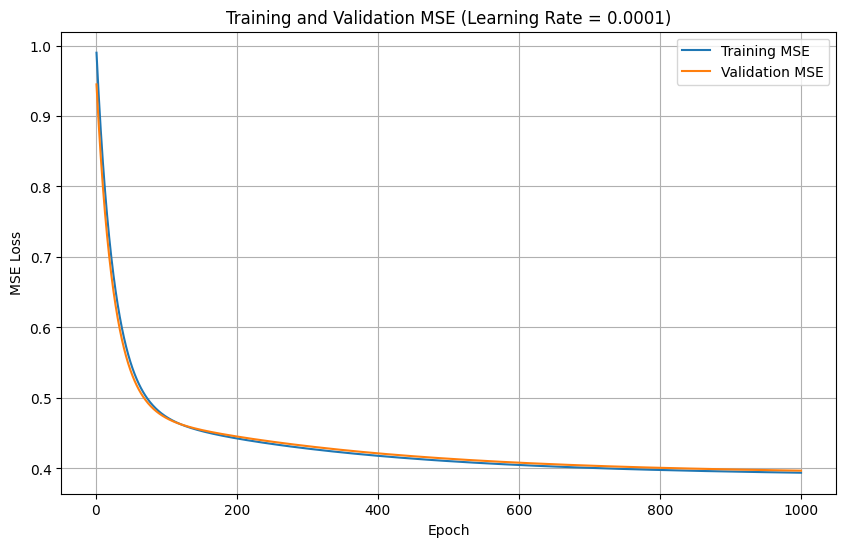

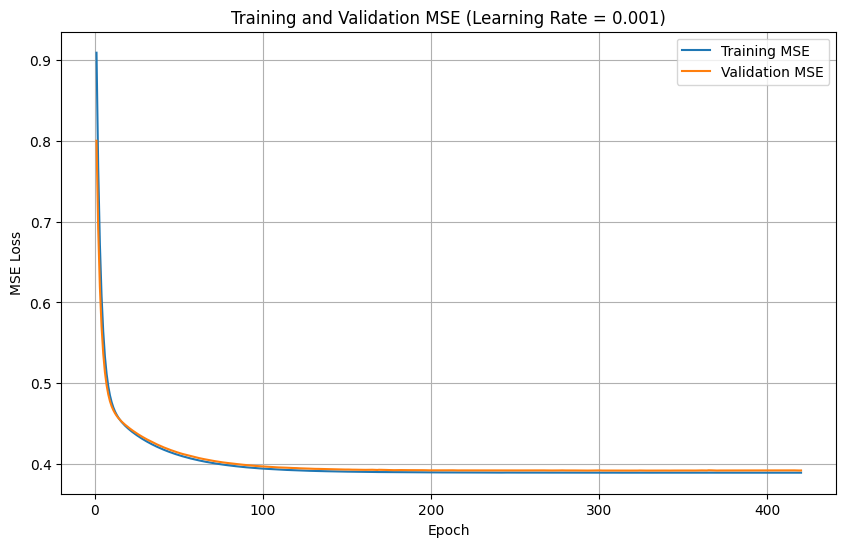

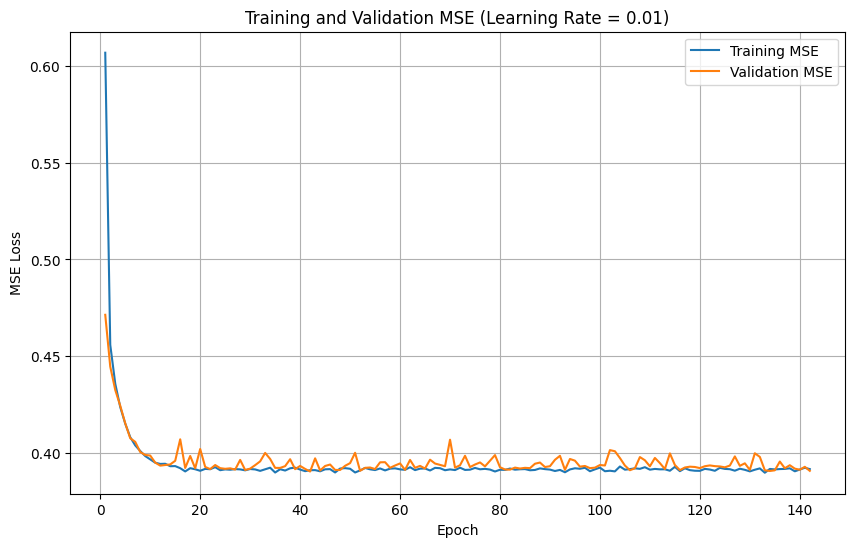

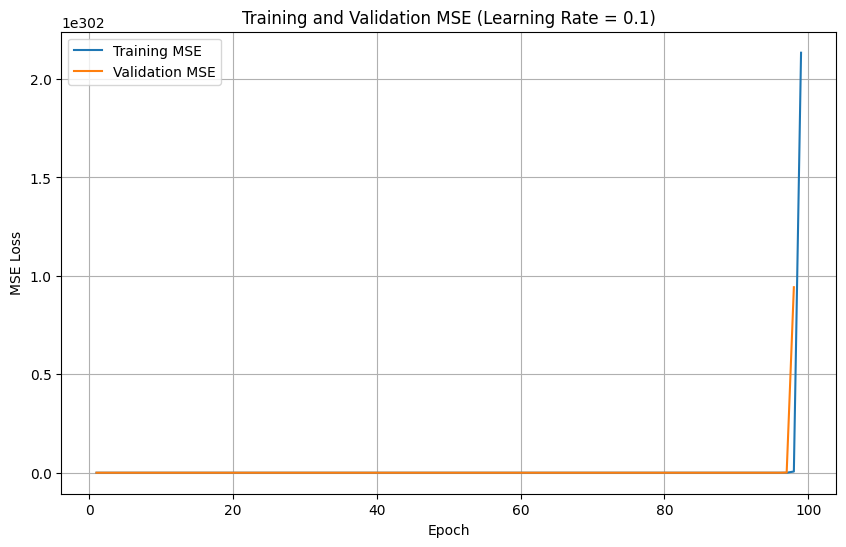

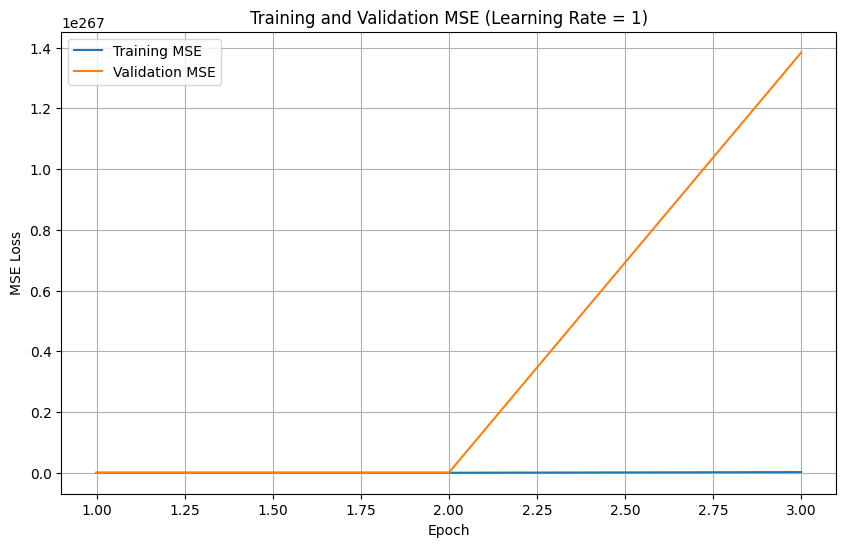

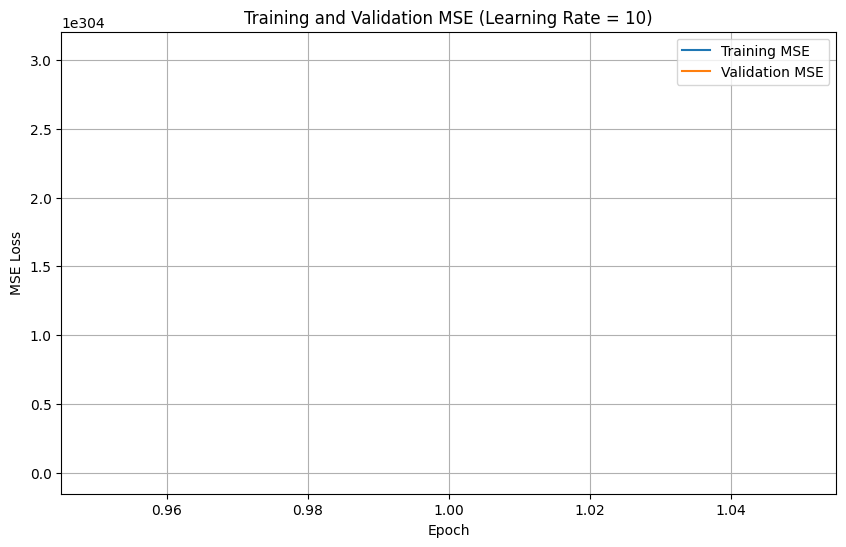

In [64]:
# ============================================================
# PLOT 7 SEPARATE GRAPHS
# ============================================================

for lr in learning_rates:

    result = results_lr[lr]

    training_losses = result["training_losses"]
    validation_losses = result["validation_losses"]

    epochs = np.arange(1, len(training_losses) + 1)

    plt.figure(figsize=(10, 6))

    # Training MSE
    plt.plot(
        epochs,
        training_losses,
        label="Training MSE"
    )

    # Validation MSE
    plt.plot(
        epochs,
        validation_losses,
        label="Validation MSE"
    )

    # Axis labels
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")

    # Title
    plt.title(
        f"Training and Validation MSE "
        f"(Learning Rate = {lr})"
    )

    # Legend
    plt.legend()

    # Grid
    plt.grid(True)

    # Show plot
    plt.show()

# TASK - 4 Effect of Batch Size


In [65]:
# The best learning rate obtained from Task 3
print("Best learning rate from Task 3:", best_learning_rate)


# ============================================================
# BATCH SIZES REQUIRED BY THE LAB
# ============================================================

# 1, 16, 32, 64, 128, 256
# and the entire training dataset

batch_sizes = [
    1,
    16,
    32,
    64,
    128,
    256,
    X_train.shape[0]
]


# ============================================================
# STORE RESULTS
# ============================================================

results_batch = {}


# ============================================================
# TRAIN MODEL FOR EACH BATCH SIZE
# ============================================================

for batch_size in batch_sizes:

    print("\n" + "=" * 70)

    if batch_size == X_train.shape[0]:
        print("Training with Batch Size = Entire Training Dataset")
    else:
        print(f"Training with Batch Size = {batch_size}")

    print("=" * 70)

    # Train using the BEST learning rate from Task 3
    best_weights, training_losses, validation_losses, best_epoch, best_val_loss = (
        train_linear_regression(
            X_train,
            y_train,
            X_val,
            y_val,
            learning_rate=best_learning_rate,
            batch_size=batch_size
        )
    )

    # Store results
    results_batch[batch_size] = {
        "weights": best_weights,
        "training_losses": training_losses,
        "validation_losses": validation_losses,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss
    }

Best learning rate from Task 3: 0.01

Training with Batch Size = 1
Epoch    1 | Training MSE: 489.184091 | Validation MSE: 16312.291425
Epoch   50 | Training MSE: 356773387540669308779430511040905773039213078132924496127526827846467391357225943319759133322853677479443701630684070308606565445191337286056473564411605503490470813943669451256148944713273488736258779377486018311024753973291048415760769385672199230294327296.000000 | Validation MSE: 45386095038175991886644145194329560905765607155365088747937738029472070431339629343624706652501294633940484176107300706466804352112459775015763723206888307126425560288898304183077617622523275776894296290002048674267381608694544100783156719578194523858141184.000000


/tmp/ipykernel_2577/3969266931.py:95: RuntimeWarning: overflow encountered in scalar add
  total_squared_error += np.sum(batch_error ** 2)
/tmp/ipykernel_2577/3114372848.py:13: RuntimeWarning: overflow encountered in square
  mse = np.mean(error ** 2)
/tmp/ipykernel_2577/3969266931.py:84: RuntimeWarning: overflow encountered in square
  batch_mse = np.mean(batch_error ** 2)
/tmp/ipykernel_2577/3969266931.py:95: RuntimeWarning: overflow encountered in square
  total_squared_error += np.sum(batch_error ** 2)


Epoch  100 | Training MSE: inf | Validation MSE: inf

Early stopping at epoch 101

Training with Batch Size = 16
Epoch    1 | Training MSE: 0.466351 | Validation MSE: 1.675208
Epoch   50 | Training MSE: 205673586219324643830238831229924648310685534923419443079373123638208201813901215880761492788363861956804133199442849463594620154806272.000000 | Validation MSE: 19917698743784645134292083515780669415399287291444440678966266907694422889942703600070134513828961981073594232358904189543071811301801984.000000
Epoch  100 | Training MSE: 199130790159253869013504625108894189227450403428107452743789557113407860674452738511753634621164925142892029380322593567104302195545946473458106275234046224376184855557994324120773453711230328298507448761448390330007001364218586072633085199620229052389298594725335350116352.000000 | Validation MSE: 795424657337455666305114082054336734592556113094452832486842405490511621437138080686645378071121366175101651086779136669256309056141766795599639408020397746969190630

In [66]:
# ============================================================
# PRINT RESULTS TABLE
# ============================================================

print("\n\n")
print("=" * 80)
print("BATCH SIZE EXPERIMENT RESULTS")
print("=" * 80)

print(
    f"{'Batch Size':<25}"
    f"{'Lowest Validation MSE':<30}"
    f"{'Best Epoch':<15}"
)

print("-" * 80)

for batch_size in batch_sizes:

    result = results_batch[batch_size]

    if batch_size == X_train.shape[0]:
        batch_name = "Entire Training Dataset"
    else:
        batch_name = str(batch_size)

    print(
        f"{batch_name:<25}"
        f"{result['best_val_loss']:<30.6f}"
        f"{result['best_epoch']:<15}"
    )


# ============================================================
# FIND BEST BATCH SIZE
# ============================================================

best_batch_size = min(
    batch_sizes,
    key=lambda batch_size: results_batch[batch_size]["best_val_loss"]
)

best_batch_result = results_batch[best_batch_size]


# ============================================================
# DISPLAY BEST BATCH SIZE
# ============================================================

print("\n" + "=" * 80)
print("BEST BATCH SIZE")
print("=" * 80)

if best_batch_size == X_train.shape[0]:
    print("Best Batch Size: Entire Training Dataset")
else:
    print("Best Batch Size:", best_batch_size)

print(
    "Lowest Validation MSE:",
    best_batch_result["best_val_loss"]
)

print(
    "Epoch of Lowest Validation MSE:",
    best_batch_result["best_epoch"]
)




BATCH SIZE EXPERIMENT RESULTS
Batch Size               Lowest Validation MSE         Best Epoch     
--------------------------------------------------------------------------------
1                        16312.291425                  1              
16                       1.675208                      1              
32                       3.196844                      1              
64                       0.390506                      255            
128                      0.390492                      138            
256                      0.390739                      96             
Entire Training Dataset  0.396396                      1000           

BEST BATCH SIZE
Best Batch Size: 128
Lowest Validation MSE: 0.3904923616903409
Epoch of Lowest Validation MSE: 138


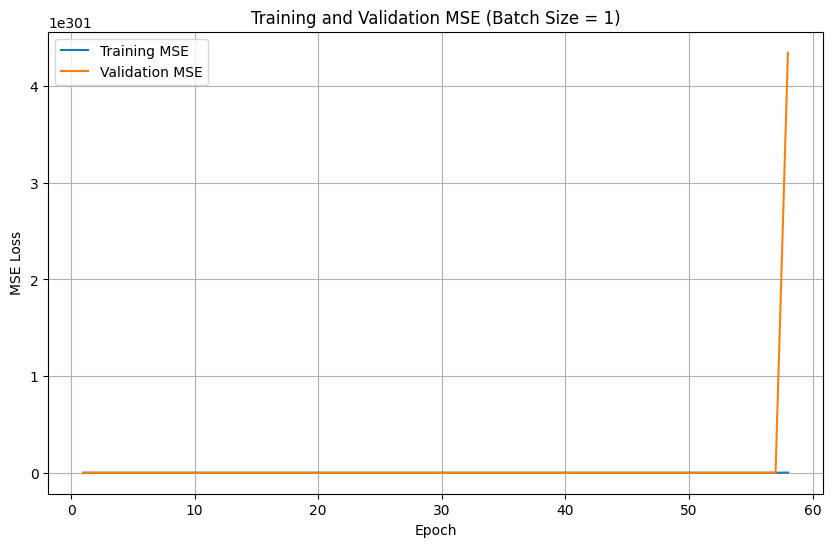

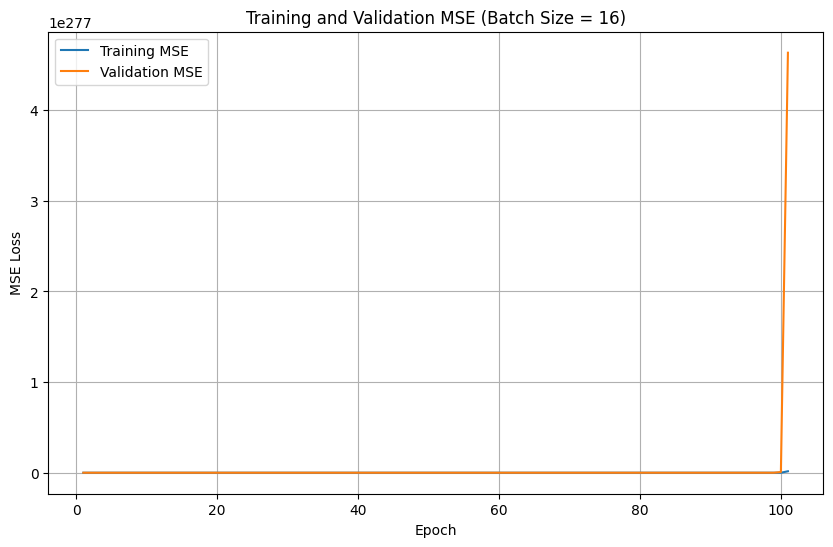

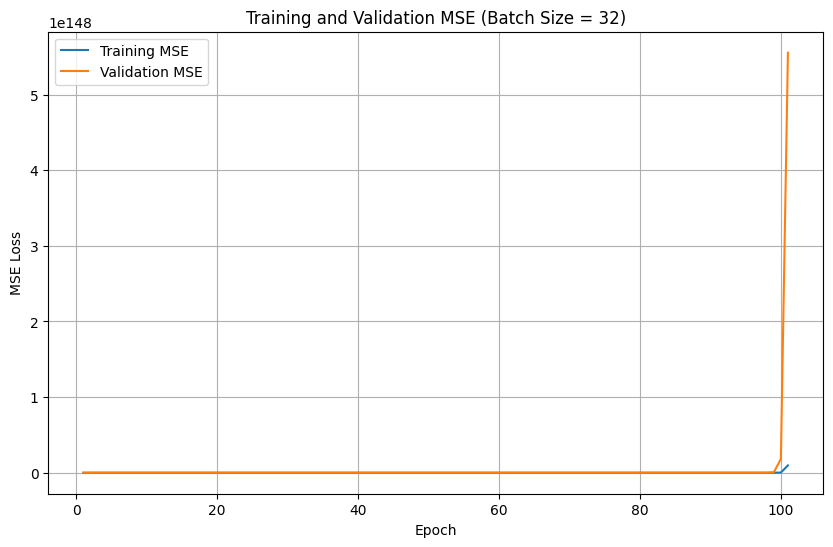

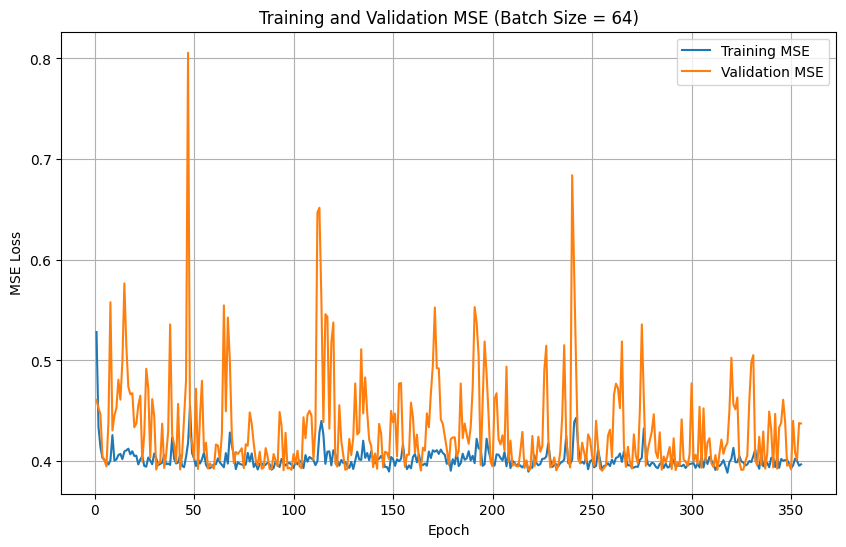

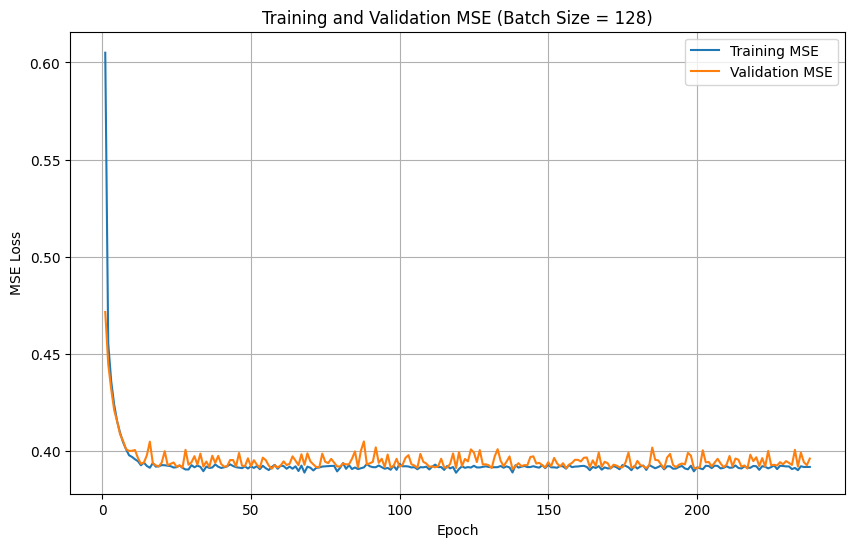

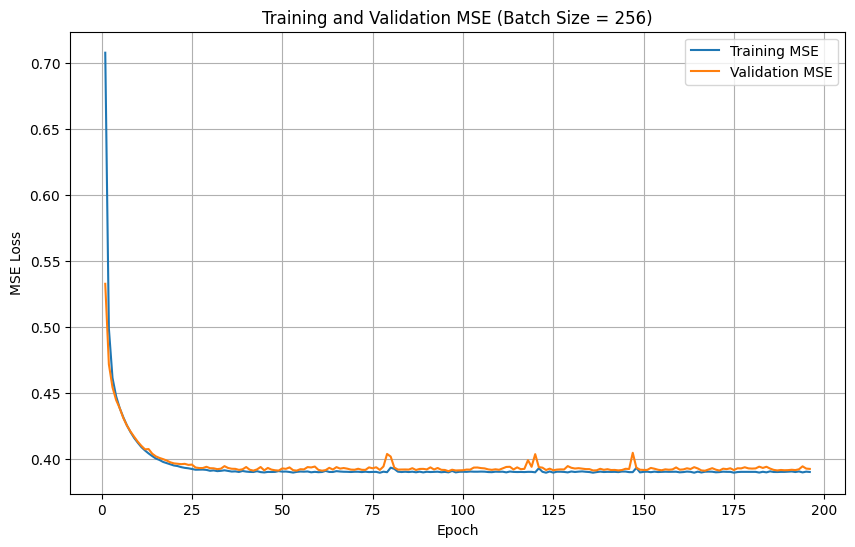

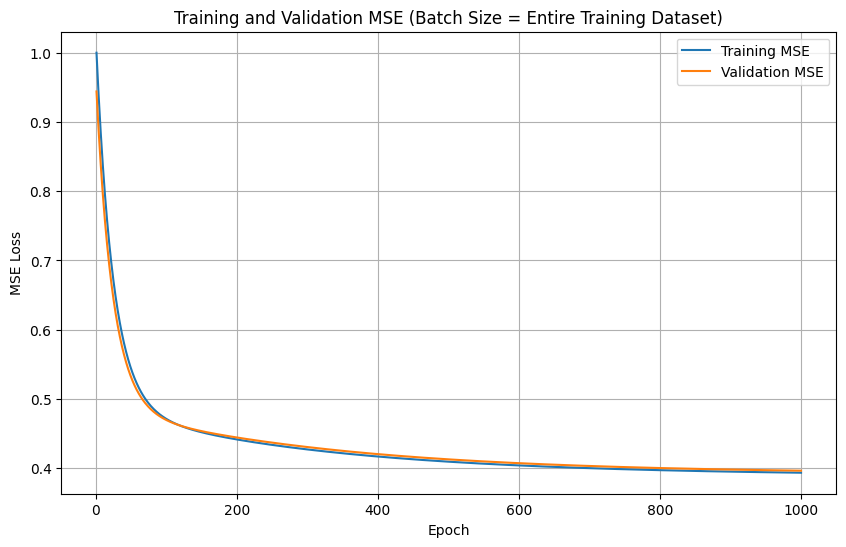

In [67]:
# ============================================================
# PLOT 7 SEPARATE GRAPHS
# ============================================================

for batch_size in batch_sizes:

    result = results_batch[batch_size]

    training_losses = result["training_losses"]
    validation_losses = result["validation_losses"]

    epochs = np.arange(1, len(training_losses) + 1)


    # Create a separate figure
    plt.figure(figsize=(10, 6))


    # Training MSE
    plt.plot(
        epochs,
        training_losses,
        label="Training MSE"
    )


    # Validation MSE
    plt.plot(
        epochs,
        validation_losses,
        label="Validation MSE"
    )


    # X-axis
    plt.xlabel("Epoch")


    # Y-axis
    plt.ylabel("MSE Loss")


    # Title
    if batch_size == X_train.shape[0]:

        plt.title(
            "Training and Validation MSE "
            "(Batch Size = Entire Training Dataset)"
        )

    else:

        plt.title(
            f"Training and Validation MSE "
            f"(Batch Size = {batch_size})"
        )


    # Legend
    plt.legend()


    # Grid
    plt.grid(True)


    # Display plot
    plt.show()

# TASK - 5 Inference on Test Set

In [68]:
import matplotlib.pyplot as plt


# ============================================================
# 1. GET THE BEST MODEL FROM TASK 4
# ============================================================

best_model_weights = results_batch[best_batch_size]["weights"]

print("=" * 70)
print("BEST MODEL")
print("=" * 70)

print("Best Learning Rate:", best_learning_rate)

if best_batch_size == X_train.shape[0]:
    print("Best Batch Size: Entire Training Dataset")
else:
    print("Best Batch Size:", best_batch_size)

BEST MODEL
Best Learning Rate: 0.01
Best Batch Size: 128


In [69]:
# ============================================================
# 2. MAKE PREDICTIONS
# ============================================================

# Predictions are currently in the STANDARDIZED target scale

y_train_pred_standardized = X_train @ best_model_weights

y_val_pred_standardized = X_val @ best_model_weights

y_test_pred_standardized = X_test @ best_model_weights


# ============================================================
# 3. CONVERT PREDICTIONS BACK TO ORIGINAL TARGET SCALE
# ============================================================

# Original value = standardized value * training_std + training_mean

y_train_pred = (
    y_train_pred_standardized * y_std + y_mean
)

y_val_pred = (
    y_val_pred_standardized * y_std + y_mean
)

y_test_pred = (
    y_test_pred_standardized * y_std + y_mean
)


# ============================================================
# 4. CONVERT ACTUAL TARGET VALUES BACK TO ORIGINAL SCALE
# ============================================================

y_train_original = (
    y_train * y_std + y_mean
)

y_val_original = (
    y_val * y_std + y_mean
)

y_test_original = (
    y_test * y_std + y_mean
)


In [70]:
# ============================================================
# 5. DEFINE PERFORMANCE METRICS
# ============================================================

def calculate_rmse(y_true, y_pred):

    mse = np.mean((y_true - y_pred) ** 2)

    rmse = np.sqrt(mse)

    return rmse


def calculate_mae(y_true, y_pred):

    mae = np.mean(np.abs(y_true - y_pred))

    return mae


def calculate_mape(y_true, y_pred):

    # Avoid division by zero
    non_zero = y_true != 0

    mape = np.mean(
        np.abs(
            (y_true[non_zero] - y_pred[non_zero])
            / y_true[non_zero]
        )
    ) * 100

    return mape


def calculate_r_squared(y_true, y_pred):

    ss_res = np.sum(
        (y_true - y_pred) ** 2
    )

    ss_tot = np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

    r_squared = 1 - (ss_res / ss_tot)

    return r_squared


# ============================================================
# 6. CALCULATE METRICS FOR TRAINING SET
# ============================================================

train_rmse = calculate_rmse(
    y_train_original,
    y_train_pred
)

train_mape = calculate_mape(
    y_train_original,
    y_train_pred
)

train_mae = calculate_mae(
    y_train_original,
    y_train_pred
)

train_r2 = calculate_r_squared(
    y_train_original,
    y_train_pred
)

In [71]:
# ============================================================
# 7. CALCULATE METRICS FOR VALIDATION SET
# ============================================================

val_rmse = calculate_rmse(
    y_val_original,
    y_val_pred
)

val_mape = calculate_mape(
    y_val_original,
    y_val_pred
)

val_mae = calculate_mae(
    y_val_original,
    y_val_pred
)

val_r2 = calculate_r_squared(
    y_val_original,
    y_val_pred
)


# ============================================================
# 8. CALCULATE METRICS FOR TEST SET
# ============================================================

test_rmse = calculate_rmse(
    y_test_original,
    y_test_pred
)

test_mape = calculate_mape(
    y_test_original,
    y_test_pred
)

test_mae = calculate_mae(
    y_test_original,
    y_test_pred
)

test_r2 = calculate_r_squared(
    y_test_original,
    y_test_pred
)


In [72]:
# ============================================================
# 9. CREATE RESULTS TABLE
# ============================================================

print("\n" + "=" * 80)
print("MODEL PERFORMANCE")
print("=" * 80)

print(
    f"{'Dataset':<15}"
    f"{'RMSE':<15}"
    f"{'MAPE (%)':<15}"
    f"{'MAE':<15}"
    f"{'R-squared':<15}"
)

print("-" * 80)

print(
    f"{'Training':<15}"
    f"{train_rmse:<15.6f}"
    f"{train_mape:<15.6f}"
    f"{train_mae:<15.6f}"
    f"{train_r2:<15.6f}"
)

print(
    f"{'Validation':<15}"
    f"{val_rmse:<15.6f}"
    f"{val_mape:<15.6f}"
    f"{val_mae:<15.6f}"
    f"{val_r2:<15.6f}"
)

print(
    f"{'Test':<15}"
    f"{test_rmse:<15.6f}"
    f"{test_mape:<15.6f}"
    f"{test_mae:<15.6f}"
    f"{test_r2:<15.6f}"
)


MODEL PERFORMANCE
Dataset        RMSE           MAPE (%)       MAE            R-squared      
--------------------------------------------------------------------------------
Training       0.722910       31.621207      0.528563       0.609886       
Validation     0.723261       31.472591      0.533864       0.595113       
Test           0.730071       31.300690      0.532276       0.603931       


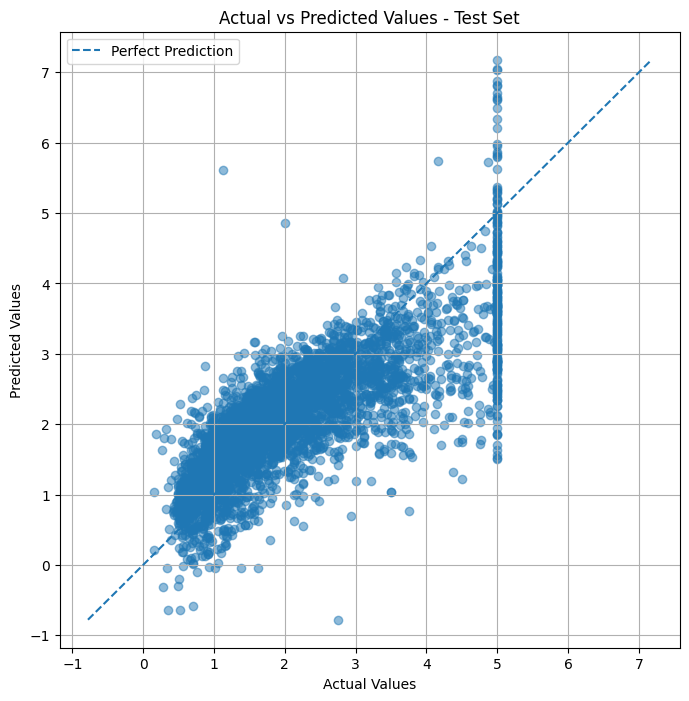

In [73]:
# ============================================================
# 10. ACTUAL VS PREDICTED PLOT
# ============================================================

plt.figure(figsize=(8, 8))

# Scatter plot
plt.scatter(
    y_test_original,
    y_test_pred,
    alpha=0.5
)


# Create ideal prediction line
min_value = min(
    np.min(y_test_original),
    np.min(y_test_pred)
)

max_value = max(
    np.max(y_test_original),
    np.max(y_test_pred)
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect Prediction"
)


# Axis labels
plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")


# Title
plt.title("Actual vs Predicted Values - Test Set")


# Legend
plt.legend()


# Grid
plt.grid(True)


# Show plot
plt.show()